In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib ipympl
from tabulate import tabulate

#Rounding
dp = 2

#Bottle parameters
p = 1
a = 3.4
b = 4
e = 4.3
theta = .7
phi = .45

d = np.sqrt(e*(e-p)/2)
H = (a+b+(a-b)*np.cos(theta))/np.sin(theta) + d
c = ((H-d)*np.sin(phi)+p*np.cos(phi)-e)/(1-np.cos(phi))

P = np.array([0,a*(1+np.cos(theta)),H-a*np.sin(theta)])
Q = np.array([0,b*(1-np.cos(theta)),d+b*np.sin(theta)])
PQ = Q-P
magPQ = np.sqrt(PQ[1]**2+PQ[2]**2)
PQhat = PQ/magPQ

t = np.array([
    0,
    d, 
    e*np.sin(phi)+d,
    H-c*np.sin(phi), 
    H, 
    H+a*(np.pi+theta), 
    H+a*(np.pi+theta)+magPQ, 
    H+a*(np.pi+theta)+magPQ+b*theta,
    H+d+a*(np.pi+theta)+magPQ+b*theta
])

n=1000

usplit = [np.linspace(-np.pi, 0, n),   
          np.linspace(t[1], t[2], 2*n),
          np.linspace(t[2], t[3], n),
          np.linspace(t[3], t[4], n),
          np.linspace(t[4], t[5], n),
          np.linspace(t[5], t[6], n),
          np.linspace(t[6], t[7], n),
          np.linspace(t[7], t[8], n)]


#Bottle canal 1
u = usplit[1]
r1 = np.sqrt(e**2-(u-d)**2)
r1dot = -(u-d)/np.sqrt(e**2-(u-d)**2)
r1ddot = -e**2*np.power((e**2-(u-d)**2),-1.5)

#Bottle canal 2
u = usplit[2]
r2 = e/np.cos(phi)-(u-d)*np.tan(phi)
r2dot = -np.tan(phi)*np.ones(len(u))
r2ddot = np.zeros(len(u))

#Bottle canal 3
u = usplit[3]
r3 = p+c-np.sqrt(c**2-(u-t[4])**2)
r3dot = (u-t[4])/np.sqrt(c**2-(u-t[4])**2)
r3ddot = c**2*np.power(c**2-(u-H)**2,-1.5)


#Pattern
#base
u0 = usplit[0]
z0 = d+d*np.sin(u0)
E0 = ( (e-p)*np.sin(u0)/2 )**2 + ( d*np.cos(u0) )**2
G0 = ((e+p)/2+((e-p)/2*np.cos(u0)))**2
l = len(u0)
du0 = np.zeros(l)
for j in range(1,l):
    du0[j] = u0[j]-u0[j-1]

#canal
u = np.concatenate([usplit[1][1:],usplit[2][1:],usplit[3][1:]])
r = np.concatenate([r1[1:],r2[1:],r3[1:]])
rdot = np.concatenate([r1dot[1:],r2dot[1:],r3dot[1:]])
rddot = np.concatenate([r1ddot[1:],r2ddot[1:],r3ddot[1:]])
z = np.zeros(l)
z = u-r*rdot
E = (1-r*rddot-rdot**2)**2 + (rdot**2*(1-rdot**2-r*rddot)**2)/(1-rdot**2)
G = r**2*(1-rdot**2)
l = len(u)
du = np.zeros(l)
for j in range(1,l):
    du[j] = u[j]-u[j-1]

#add base
u = np.concatenate([usplit[0],u])
z = np.concatenate([z0,z])
E = np.concatenate([E0,E])
G = np.concatenate([G0,G])
du = np.concatenate([du0,du])

ds = np.sqrt(E)*du

l = len(u)
dz = np.zeros(l)
for j in range(1,l):
    dz[j] = z[j]-z[j-1]

s = np.zeros(l)
for j in range(1,l):
    s[j] = s[j-1]+ds[j]

#stitch dimensions
w = .4
h = .4

row = [int(i/h) for i in s]

#circumference
C = 2*np.pi*np.sqrt(G)
st_count = np.round(C/w)

data = np.transpose([row,
                     st_count,
                     u,#r,rdot,rddot,
                     z,
                     E,
                     G,
                     du,
                     dz,
                     ds,
                     s,
                     C])

index=[0]
for j in range(1,l):
    if row[j]>row[j-1]:
        index = np.append(index,j)

index = [int(i) for i in index]

data = data[index]

table = tabulate(data,headers=['Row','Stitch count','u','z','E','G','du','dz','ds','s','Circumference'],tablefmt='html')

print('Number of rows: ',max(row))
print('Stitch width: ',w)
print('Stitch height: ',h)
display(table)

Number of rows:  45
Stitch width:  0.4
Stitch height:  0.4


Row,Stitch count,u,z,E,G,du,dz,ds,s,Circumference
0,16,-3.14159,2.66364,7.095,1,0,0,0,0,6.28319
1,16,-2.99065,2.2631,6.99613,1.03788,0.00314474,-0.00828318,0.00831789,0.401102,6.40107
2,17,-2.83655,1.86367,6.70061,1.15815,0.00314474,-0.00799371,0.00814032,0.804711,6.76179
3,18,-2.67932,1.47569,6.22529,1.37636,0.00314474,-0.00750313,0.00784629,1.20467,7.37134
4,21,-2.51579,1.10342,5.59479,1.72315,0.00314474,-0.00679677,0.00743835,1.60227,8.24785
5,24,-2.33968,0.749325,4.83657,2.25809,0.00314474,-0.00583392,0.00691597,2.00423,9.44171
6,27,-2.151,0.435903,4.03651,3.0467,0.00314474,-0.00460294,0.00631811,2.40097,10.9672
7,32,-1.9403,0.179781,3.29282,4.2193,0.00314474,-0.00303748,0.00570648,2.8028,12.9063
8,38,-1.71074,0.0260391,2.80757,5.85568,0.00314474,-0.00118143,0.00526926,3.2012,15.2044
9,44,-1.46859,0.0138996,2.76801,7.94306,0.00314474,0.000841514,0.00523201,3.60239,17.7082


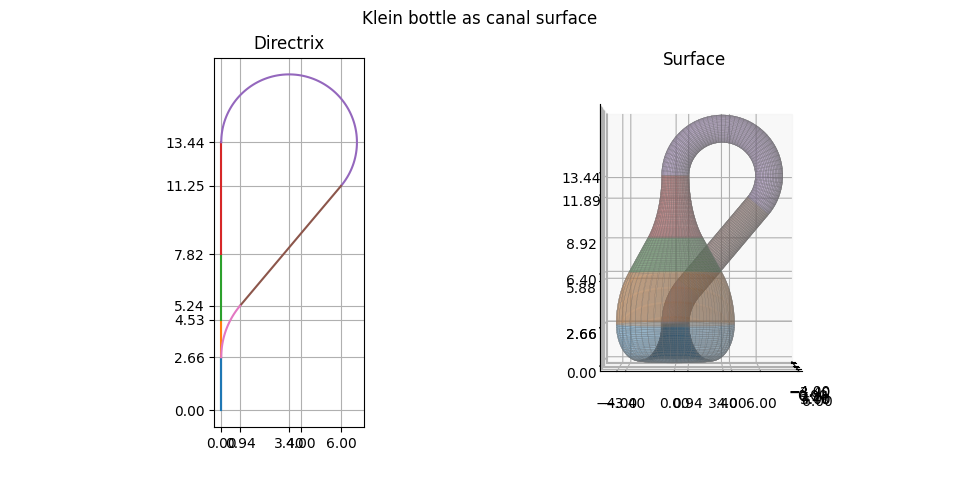

In [3]:

import numpy as np
import matplotlib.pyplot as plt

from matplotlib import cm
%matplotlib ipympl

#Rounding
dp = 2

#Bottle parameters
p = 1
a = 3.4
b = 4
e = 4.3
theta = .7
phi = .45

d = np.sqrt(e*(e-p)/2)
H = (a+b+(a-b)*np.cos(theta))/np.sin(theta) + d
c = ((H-d)*np.sin(phi)+p*np.cos(phi)-e)/(1-np.cos(phi))

P = np.array([0,a*(1+np.cos(theta)),H-a*np.sin(theta)])
Q = np.array([0,b*(1-np.cos(theta)),d+b*np.sin(theta)])
PQ = Q-P
magPQ = np.sqrt(PQ[1]**2+PQ[2]**2)
PQhat = PQ/magPQ

t = np.array([
    0,
    d, 
    e*np.sin(phi)+d,
    H-c*np.sin(phi), 
    H, 
    H+a*(np.pi+theta), 
    H+a*(np.pi+theta)+magPQ, 
    H+a*(np.pi+theta)+magPQ+b*theta,
    H+d+a*(np.pi+theta)+magPQ+b*theta
])

n=100

usplit = [np.linspace(-np.pi, 0, n),   #t[0], t[1], n),
          np.linspace(t[1], t[2], 2*n),
          np.linspace(t[2], t[3], n),
          np.linspace(t[3], t[4], n),
          np.linspace(t[4], t[5], n),
          np.linspace(t[5], t[6], n),
          np.linspace(t[6], t[7], n),
          np.linspace(t[7], t[8], n)]


# Set up a figure and axes
#fig1, surf = plt.subplots(1, 1, figsize=(8, 12), subplot_kw={'projection': '3d'})
#fig2, directrix = plt.subplots(1, 1, figsize=(8, 12))

#directrix.set_title('Directrix')
#surf.set_title('Surface')

fig = plt.figure(figsize=plt.figaspect(.5))
fig.suptitle('Klein bottle as canal surface')

directrix = fig.add_subplot(1, 2, 1)
surf = fig.add_subplot(1, 2, 2, projection='3d')

directrix.set_title('Directrix')
surf.set_title('Surface')


#Base 0
#Not canal
u = usplit[0]
gamma0 = (0*u,0*u,-d*np.sin(u))
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x0 = ((e+p)/2+((e-p)/2)*np.cos(u))*np.sin(v)
y0 = ((e+p)/2+((e-p)/2)*np.cos(u))*np.cos(v)
z0 = d+d*np.sin(u)
surf.plot_surface(x0, y0, z0, edgecolor = 'gray', linewidth = .1, alpha = .25)
directrix.plot(gamma0[1],gamma0[2])

#Bottle canal 1
u = usplit[1]
r1 = np.sqrt(e**2-(u-d)**2)
r1dot = -(u-d)/np.sqrt(e**2-(u-d)**2)
r1ddot = -e**2*np.power((e**2-(u-d)**2),-1.5)
gamma1 = (0*u,0*u,u)
T = (0,0,1)
N = (0,1,0)
B = (1,0,0)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x1 = gamma1[0] - r1*r1dot*T[0] + r1*np.sqrt(1-(r1dot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y1 = gamma1[1] - r1*r1dot*T[1] + r1*np.sqrt(1-(r1dot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z1 = gamma1[2] - r1*r1dot*T[2] + r1*np.sqrt(1-(r1dot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))

surf.plot_surface(x1, y1, z1, edgecolor = 'gray', linewidth = .1, alpha = .25)
directrix.plot(gamma1[1],gamma1[2])

#Bottle canal 2
u = usplit[2]
r = e/np.cos(phi)-(u-d)*np.tan(phi)
rdot = -np.tan(phi)
gamma2 = (0*u,0*u,u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x2 = gamma2[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y2 = gamma2[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z2 = gamma2[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))
surf.plot_surface(x2, y2, z2, edgecolor = 'gray', linewidth = .1, alpha = .25)
directrix.plot(gamma2[1],gamma2[2])

#Bottle canal 3
u = usplit[3] #[H-c*np.sin(phi), H]
r = p+c-np.sqrt(c**2-(u-H)**2)
rdot = (u-H)/np.sqrt(c**2-(u-H)**2)
gamma3 = (0*u,0*u,u)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x3 = gamma3[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y3 = gamma3[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z3 = gamma3[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))
surf.plot_surface(x3, y3, z3, edgecolor = 'gray', linewidth = .1, alpha = .25)
directrix.plot(gamma3[1],gamma3[2])

#Handle 4
u = usplit[4]
r = p
rdot = 0
gamma4 = (0*u, a*(1+np.cos(np.pi-(u-t[4])/a)), H+a*np.sin(np.pi-(u-t[4])/a))
T = (0,np.sin(np.pi-(u-t[4])/a),-np.cos(np.pi-(u-t[4])/a))
N = (0,-np.cos(np.pi-(u-t[4])/a),-np.sin(np.pi-(u-t[4])/a))
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x4 = gamma4[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y4 = gamma4[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z4 = gamma4[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))
surf.plot_surface(x4, y4, z4, edgecolor = 'gray', linewidth = .1, alpha = .25)
directrix.plot(gamma4[1],gamma4[2])

#Handle 5
u = usplit[5]
gamma5 = (0*u,((u-t[5])/magPQ)*Q[1] + (1-(u-t[5])/magPQ)*P[1],((u-t[5])/magPQ)*Q[2] + (1-(u-t[5])/magPQ)*P[2])
T = (0,PQhat[1],PQhat[2])
N = (0,PQhat[2],-PQhat[1])
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x5 = gamma5[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y5 = gamma5[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z5 = gamma5[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))
surf.plot_surface(x5, y5, z5, edgecolor = 'gray', linewidth = .1, alpha = .25)
directrix.plot(gamma5[1],gamma5[2])

#Handle 6
u = usplit[6]
gamma6 = (0*u, b+b*np.cos(np.pi-theta+(u-t[6])/b), d+b*np.sin(np.pi-theta+(u-t[6])/b))
T = (0,-np.sin(np.pi-theta+(u-t[6])/b),np.cos(np.pi-theta+(u-t[6])/b))
N = (0,np.cos(np.pi-theta+(u-t[6])/b),np.sin(np.pi-theta+(u-t[6])/b))
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x6 = gamma6[0] - r*rdot*T[0] + r*np.sqrt(1-(rdot)**2)*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y6 = gamma6[1] - r*rdot*T[1] + r*np.sqrt(1-(rdot)**2)*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z6 = gamma6[2] - r*rdot*T[2] + r*np.sqrt(1-(rdot)**2)*(N[2]*np.cos(v)+B[2]*np.sin(v))
surf.plot_surface(x6, y6, z6, edgecolor = 'gray', linewidth = .1, alpha = .25)
directrix.plot(gamma6[1],gamma6[2])

#Base 7
u = usplit[7]
r = (p+e)/2-((e-p)/2)*np.sqrt(1-((u-u[0])/d)**2)
gamma7 = (0*u,0*u,H+d+a*(np.pi+theta)+magPQ+b*theta-u)
T = (0,0,-1)
N = (0,-1,0)
v = np.linspace(0,2*np.pi,100)
u, v = np.meshgrid(u, v)
x7 = gamma7[0] + r*(N[0]*np.cos(v)+B[0]*np.sin(v)) 
y7 = gamma7[1] + r*(N[1]*np.cos(v)+B[1]*np.sin(v)) 
z7 = gamma7[2] + r*(N[2]*np.cos(v)+B[2]*np.sin(v))
surf.plot_surface(x7, y7, z7, edgecolor = 'gray', linewidth = .1, alpha = .25)
#directrix.plot(gamma7[1],gamma7[2])

surf.set_aspect('equal')
surf.view_init(elev=0, azim=0, roll=0)
xyticks = [-b,-a,0,a,b,P[1],Q[1]]
zticks = [0,d,z2[0,0],z3[0,0],z4[0,0],z5[0,0],z6[0,0],z7[0,0]]
surf.set_xticks(xyticks)
surf.set_yticks(xyticks)
surf.set_zticks(zticks)

directrix.set_aspect('equal')
directrix.set_xticks([0,a,b,P[1],Q[1]])
directrix.set_yticks([t[0],t[1],t[2],t[3],t[4],P[2],Q[2]])
directrix.grid(True)

plt.show()